In [56]:
# 1. Imports and Configuration

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Times New Roman'


print('Libraries loaded.')

Libraries loaded.


In [57]:
# 2. Data Loading

BASE = r"D:\USER DATA\One Drive\Desktop\Capsetone"

prices     = pd.read_csv(os.path.join(BASE, 'prices.csv'))
prices_adj = pd.read_csv(os.path.join(BASE, 'prices-split-adjusted.csv'))
funds      = pd.read_csv(os.path.join(BASE, 'fundamentals.csv'))
sec        = pd.read_csv(os.path.join(BASE, 'securities.csv'))

print('prices     :', prices.shape)
print('prices_adj :', prices_adj.shape)
print('funds      :', funds.shape)
print('sec        :', sec.shape)

prices     : (851264, 7)
prices_adj : (851264, 7)
funds      : (1781, 79)
sec        : (505, 8)


In [58]:
print('--- prices ---')
display(prices.head(3))

print('--- prices_adj ---')
display(prices_adj.head(3))

print('--- fundamentals ---')
display(funds.head(3))

print('--- securities ---')
display(sec.head(3))

--- prices ---


,date,symbol,open,close,low,high,volume
0,1/5/2016 0:00,WLTW,123,126,122,126,2163600
1,1/6/2016 0:00,WLTW,125,120,120,126,2386400
2,1/7/2016 0:00,WLTW,116,115,115,120,2489500


--- prices_adj ---


,date,symbol,open,close,low,high,volume
0,1/5/2016,WLTW,123,126,122,126,2163600
1,1/6/2016,WLTW,125,120,120,126,2386400
2,1/7/2016,WLTW,116,115,115,120,2489500


--- fundamentals ---


,column1,ticker_symbol,period_ending,accounts_payable,accounts_receivable,additional_income_expense_items,after_tax_roe,capital_expenditures,capital_surplus,cash_ratio,...,total_current_assets,total_current_liabilities,total_equity,total_liabilities,total_liabilities_equity,total_revenue,treasury_stock,for_year,earnings_per_share,estimated_shares_outstanding
0,0,AAL,41274,"3,068,000,000",-222000000,-1961000000,23,-1888000000,"4,695,000,000",53,...,"7,072,000,000",9011000000,"-7,987,000,000","24,891,000,000","16,904,000,000","24,855,000,000","-367,000,000",2012,-5.6,335000000
1,1,AAL,41639,"4,975,000,000",-93000000,-2723000000,67,-3114000000,"10,592,000,000",75,...,"14,323,000,000",13806000000,"-2,731,000,000","45,009,000,000","42,278,000,000","26,743,000,000",0,2013,-11.25,163022222.2
2,2,AAL,42004,"4,668,000,000",-160000000,-150000000,143,-5311000000,"15,135,000,000",60,...,"11,750,000,000",13404000000,"2,021,000,000","41,204,000,000","43,225,000,000","42,650,000,000",0,2014,4.02,716915422.9


--- securities ---


,Ticker symbol,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
0,MMM,3M Company,reports,Industrials,Industrial Conglomerates,"St. Paul, Minnesota",NaN,66740
1,ABT,Abbott Laboratories,reports,Health Care,Health Care Equipment,"North Chicago, Illinois",3/31/1964,1800
2,ABBV,AbbVie,reports,Health Care,Pharmaceuticals,"North Chicago, Illinois",12/31/2012,1551152


In [59]:
# 3. Data Cleaning

# Prices: parse dates and extract time parts
prices_adj['date']      = pd.to_datetime(prices_adj['date'])
prices_adj['year']      = prices_adj['date'].dt.year
prices_adj['month']     = prices_adj['date'].dt.month
prices_adj['yearmonth'] = prices_adj['date'].dt.to_period('M')

# Fundamentals: drop rows with invalid year values
funds = funds[~funds['for_year'].isin(['Null', '1215'])].copy()
funds['for_year'] = pd.to_numeric(funds['for_year'], errors='coerce')
funds = funds.dropna(subset=['for_year'])
funds['for_year'] = funds['for_year'].astype(int)

# Cast financial metric columns to float
numeric_cols = [
    'net_income', 'total_revenue', 'profit_margin', 'quick_ratio',
    'after_tax_roe', 'earnings_per_share', 'capital_expenditures',
    'total_equity', 'total_liabilities', 'research_and_development',
    'estimated_shares_outstanding',
]
for col in numeric_cols:
    funds[col] = pd.to_numeric(funds[col], errors='coerce')

# Sector lookup table
sec_map = (
    sec[['Ticker symbol', 'Security', 'GICS Sector']]
    .rename(columns={'Ticker symbol': 'ticker_symbol', 'GICS Sector': 'sector'})
)

# Attach sector to fundamentals
funds = funds.merge(sec_map, on='ticker_symbol', how='left')

# Attach sector to prices
prices = prices.merge(
    sec_map.rename(columns={'ticker_symbol': 'symbol'})[['symbol', 'sector']],
    on='symbol', how='left',
)

print('Cleaning complete.')
print(f'  prices rows  : {len(prices):,}')
print(f'  funds rows   : {len(funds):,}')
print(f'  sectors found: {prices["sector"].nunique()}')

Cleaning complete.
  prices rows  : 851,264
  funds rows   : 1,607
  sectors found: 11


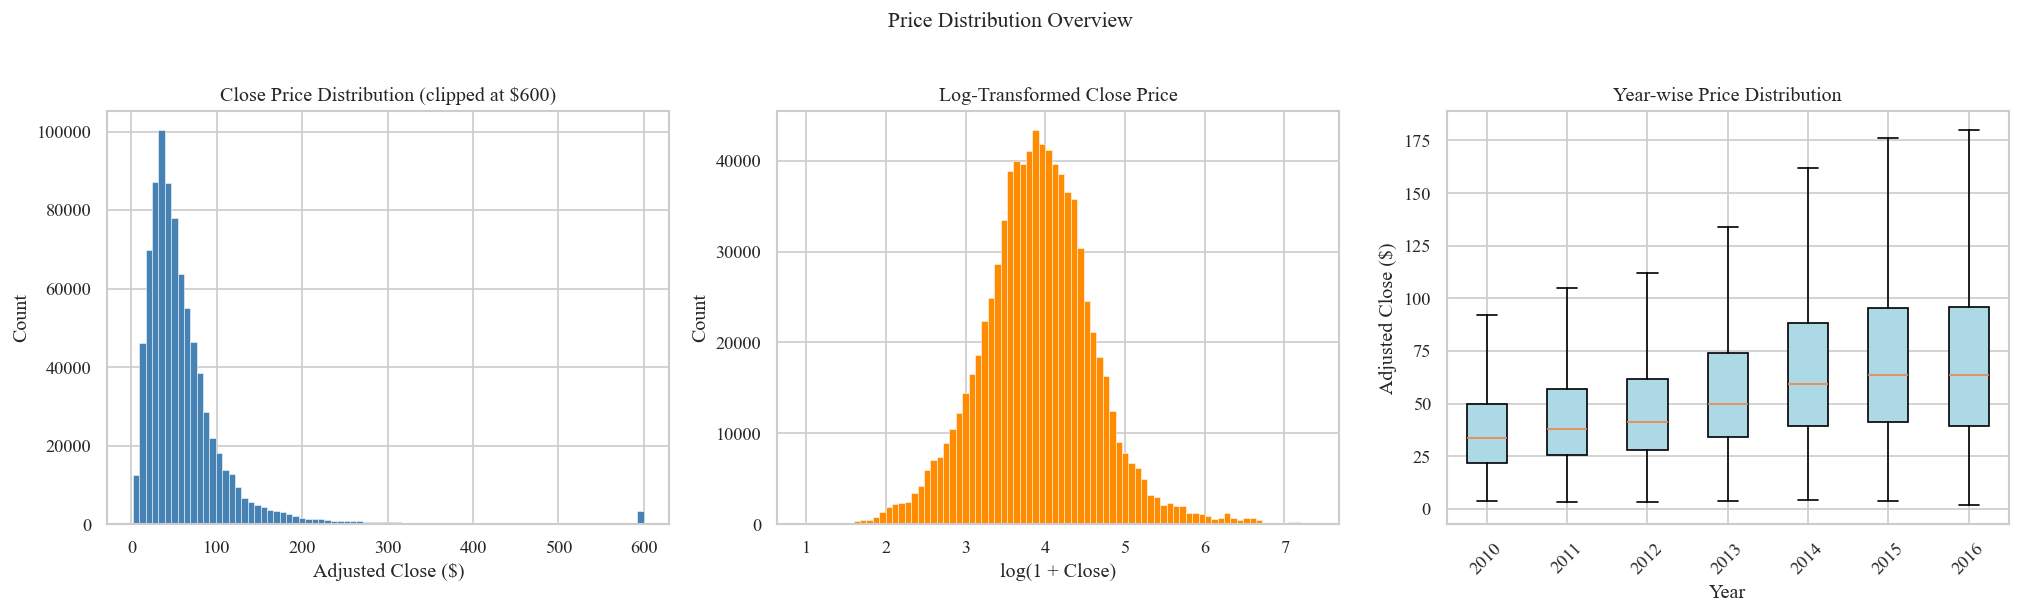

In [60]:
# 4. Exploratory Data Analysis

# 4.(a)  Adjusted Close Price Distribution

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Raw distribution clipped to remove extreme outliers for readability
axes[0].hist(prices_adj['close'].clip(0, 600), bins=80, color='steelblue',
             edgecolor='white', linewidth=0.3)
axes[0].set_title('Close Price Distribution (clipped at $600)')
axes[0].set_xlabel('Adjusted Close ($)')
axes[0].set_ylabel('Count')

# Log-transformed distribution
axes[1].hist(np.log1p(prices_adj['close']), bins=80, color='darkorange',
             edgecolor='white', linewidth=0.3)
axes[1].set_title('Log-Transformed Close Price')
axes[1].set_xlabel('log(1 + Close)')
axes[1].set_ylabel('Count')

# Year-wise box plot
years = sorted(prices_adj['year'].dropna().unique())
bp_data = [prices_adj[prices_adj['year'] == y]['close'].dropna().values for y in years]
axes[2].boxplot(bp_data, showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[2].set_xticks(range(1, len(years) + 1))
axes[2].set_xticklabels([str(int(y)) for y in years], rotation=45)
axes[2].set_title('Year-wise Price Distribution')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Adjusted Close ($)')

plt.suptitle('Price Distribution Overview', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

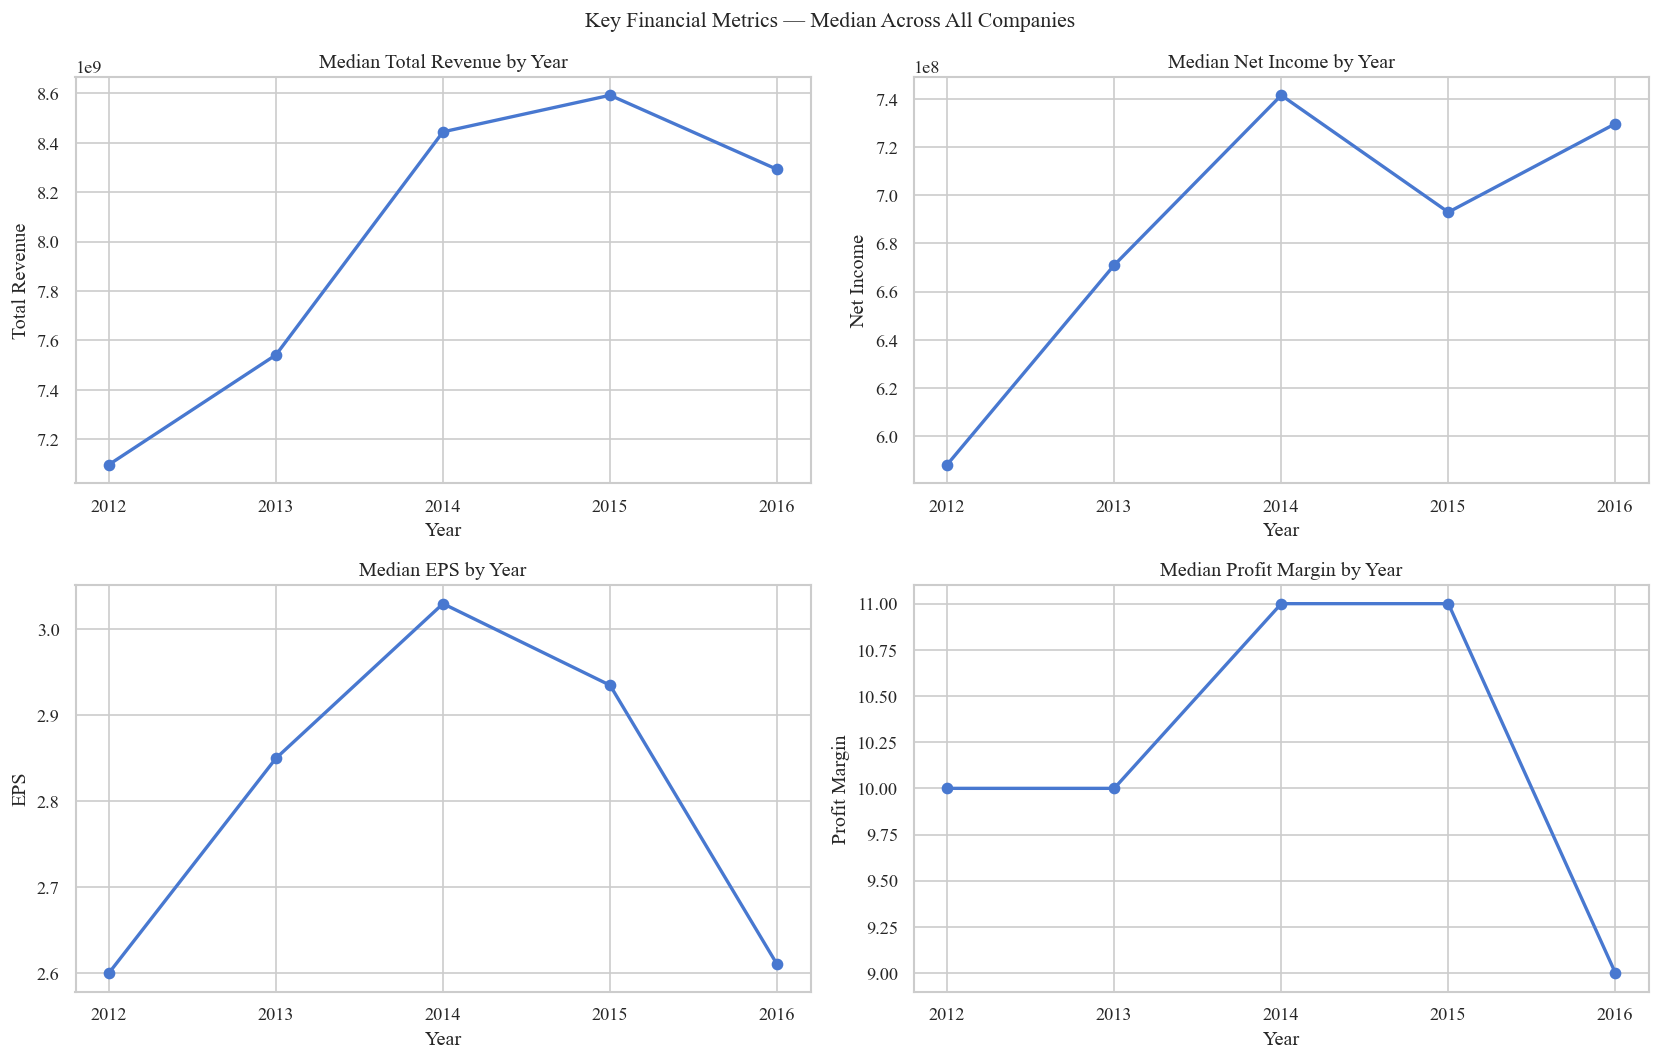

In [61]:
# 4.(b) Financial Metrics Over the Years.

metrics = ['total_revenue', 'net_income', 'earnings_per_share', 'profit_margin']
labels  = ['Total Revenue', 'Net Income', 'EPS', 'Profit Margin']

yearly = funds.groupby('for_year')[metrics].median().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col, label in zip(axes.flat, metrics, labels):
    ax.plot(yearly['for_year'], yearly[col], marker='o', linewidth=2)
    ax.set_title(f'Median {label} by Year')
    ax.set_xlabel('Year')
    ax.set_ylabel(label)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle('Key Financial Metrics — Median Across All Companies', fontsize=13)
plt.tight_layout()
plt.show()

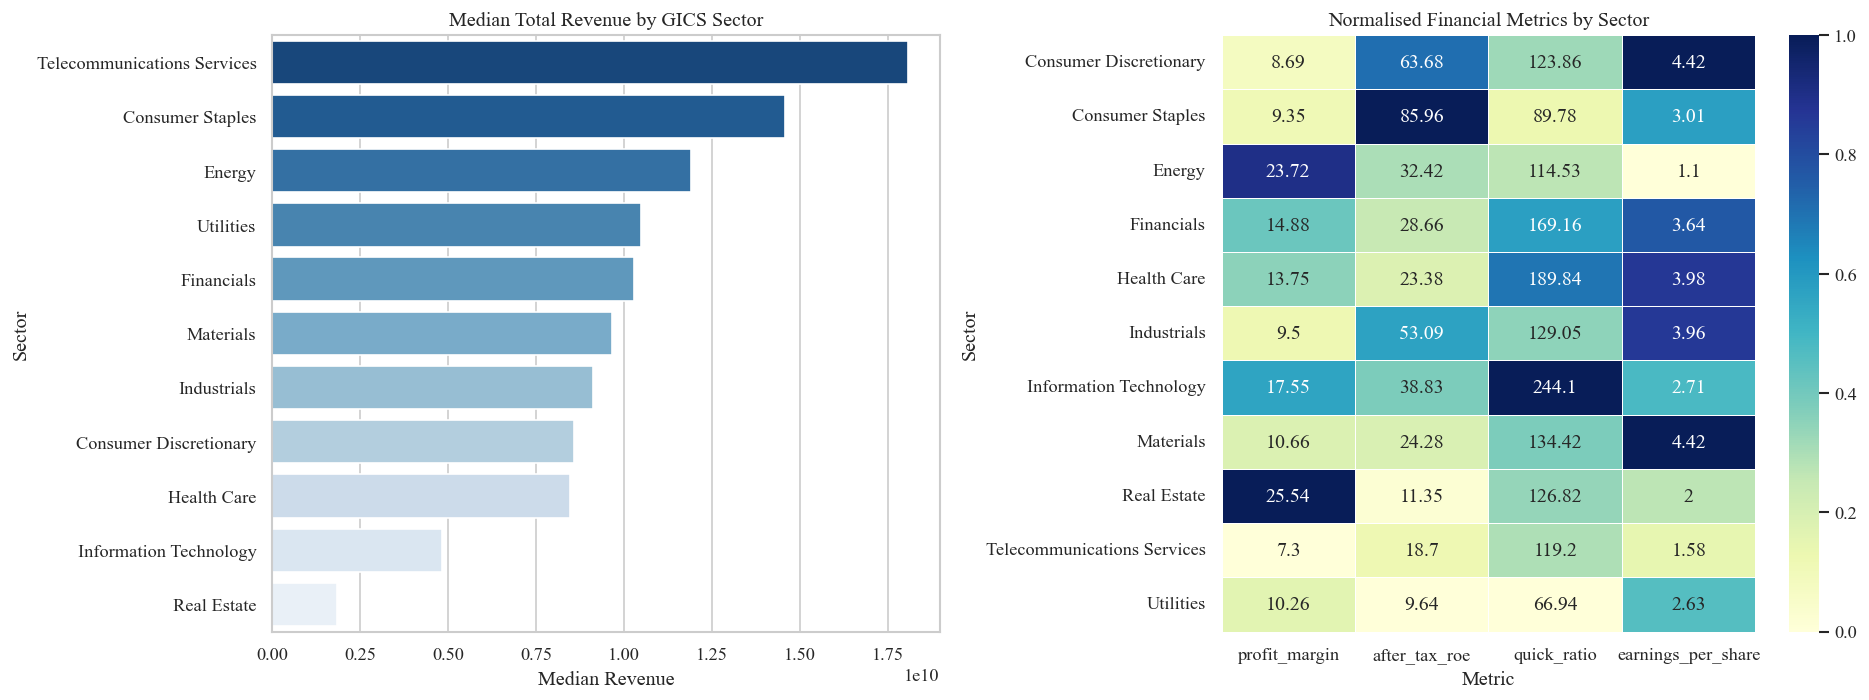

In [62]:
# 4.(c) Sector-wise Patterns.

# Median revenue per sector
sector_rev = (
    funds.dropna(subset=['sector'])
    .groupby('sector')['total_revenue']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — median revenue by sector
sns.barplot(data=sector_rev, x='total_revenue', y='sector', ax=axes[0], palette='Blues_r')
axes[0].set_title('Median Total Revenue by GICS Sector')
axes[0].set_xlabel('Median Revenue')
axes[0].set_ylabel('Sector')

# Heatmap — average financial metrics per sector
heat_df = (
    funds.dropna(subset=['sector'])
    .groupby('sector')[['profit_margin', 'after_tax_roe', 'quick_ratio', 'earnings_per_share']]
    .mean()
)
heat_norm = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min())
sns.heatmap(heat_norm, annot=heat_df.round(2), fmt='g', cmap='YlGnBu',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Normalised Financial Metrics by Sector')
axes[1].set_xlabel('Metric')
axes[1].set_ylabel('Sector')

plt.tight_layout()
plt.show()

In [63]:
# 5. Time-Series Dataset Creation.

# 5.(a) Monthly Average Adjusted Closing Price.

monthly_price = (
    prices_adj.groupby(['symbol', 'yearmonth'])['close']
    .mean()
    .reset_index()
    .rename(columns={'close': 'avg_close'})
)
monthly_price['yearmonth'] = monthly_price['yearmonth'].dt.to_timestamp()
monthly_price = monthly_price.sort_values(['symbol', 'yearmonth'])

print('Monthly price dataset shape:', monthly_price.shape)
display(monthly_price.head())


Monthly price dataset shape: (40587, 3)


,symbol,yearmonth,avg_close
0,A,2010-01-01,22
1,A,2010-02-01,22
2,A,2010-03-01,24
3,A,2010-04-01,25
4,A,2010-05-01,24


In [64]:
# 5.(b) Monthly Revenue (Approximated from Fundamentals).

# Annual revenue divided by 12 gives an approximate monthly figure
monthly_rev = funds[['ticker_symbol', 'for_year', 'total_revenue', 'sector']].copy()
monthly_rev = monthly_rev.dropna(subset=['total_revenue'])
monthly_rev['monthly_revenue'] = monthly_rev['total_revenue'] / 12

print('Monthly revenue dataset shape:', monthly_rev.shape)
display(monthly_rev.head())
pd.options.display.float_format = '{:,.0f}'.format

Monthly revenue dataset shape: (1607, 5)


,ticker_symbol,for_year,total_revenue,sector,monthly_revenue
0,AAL,2012,"24,855,000,000",Industrials,"2,071,250,000"
1,AAL,2013,"26,743,000,000",Industrials,"2,228,583,333"
2,AAL,2014,"42,650,000,000",Industrials,"3,554,166,667"
3,AAL,2015,"40,990,000,000",Industrials,"3,415,833,333"
4,AAP,2012,"6,205,003,000",Consumer Discretionary,"517,083,583"


In [65]:
# 6. Trend and Seasonality Detection.

# 6.(a)Select Top 5 Companies by Data Availability.

top5 = (
    monthly_price.groupby('symbol')['avg_close']
    .count()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)
print('Top 5 companies selected:', top5)

Top 5 companies selected: ['ZION', 'A', 'AAL', 'AAP', 'WMT']


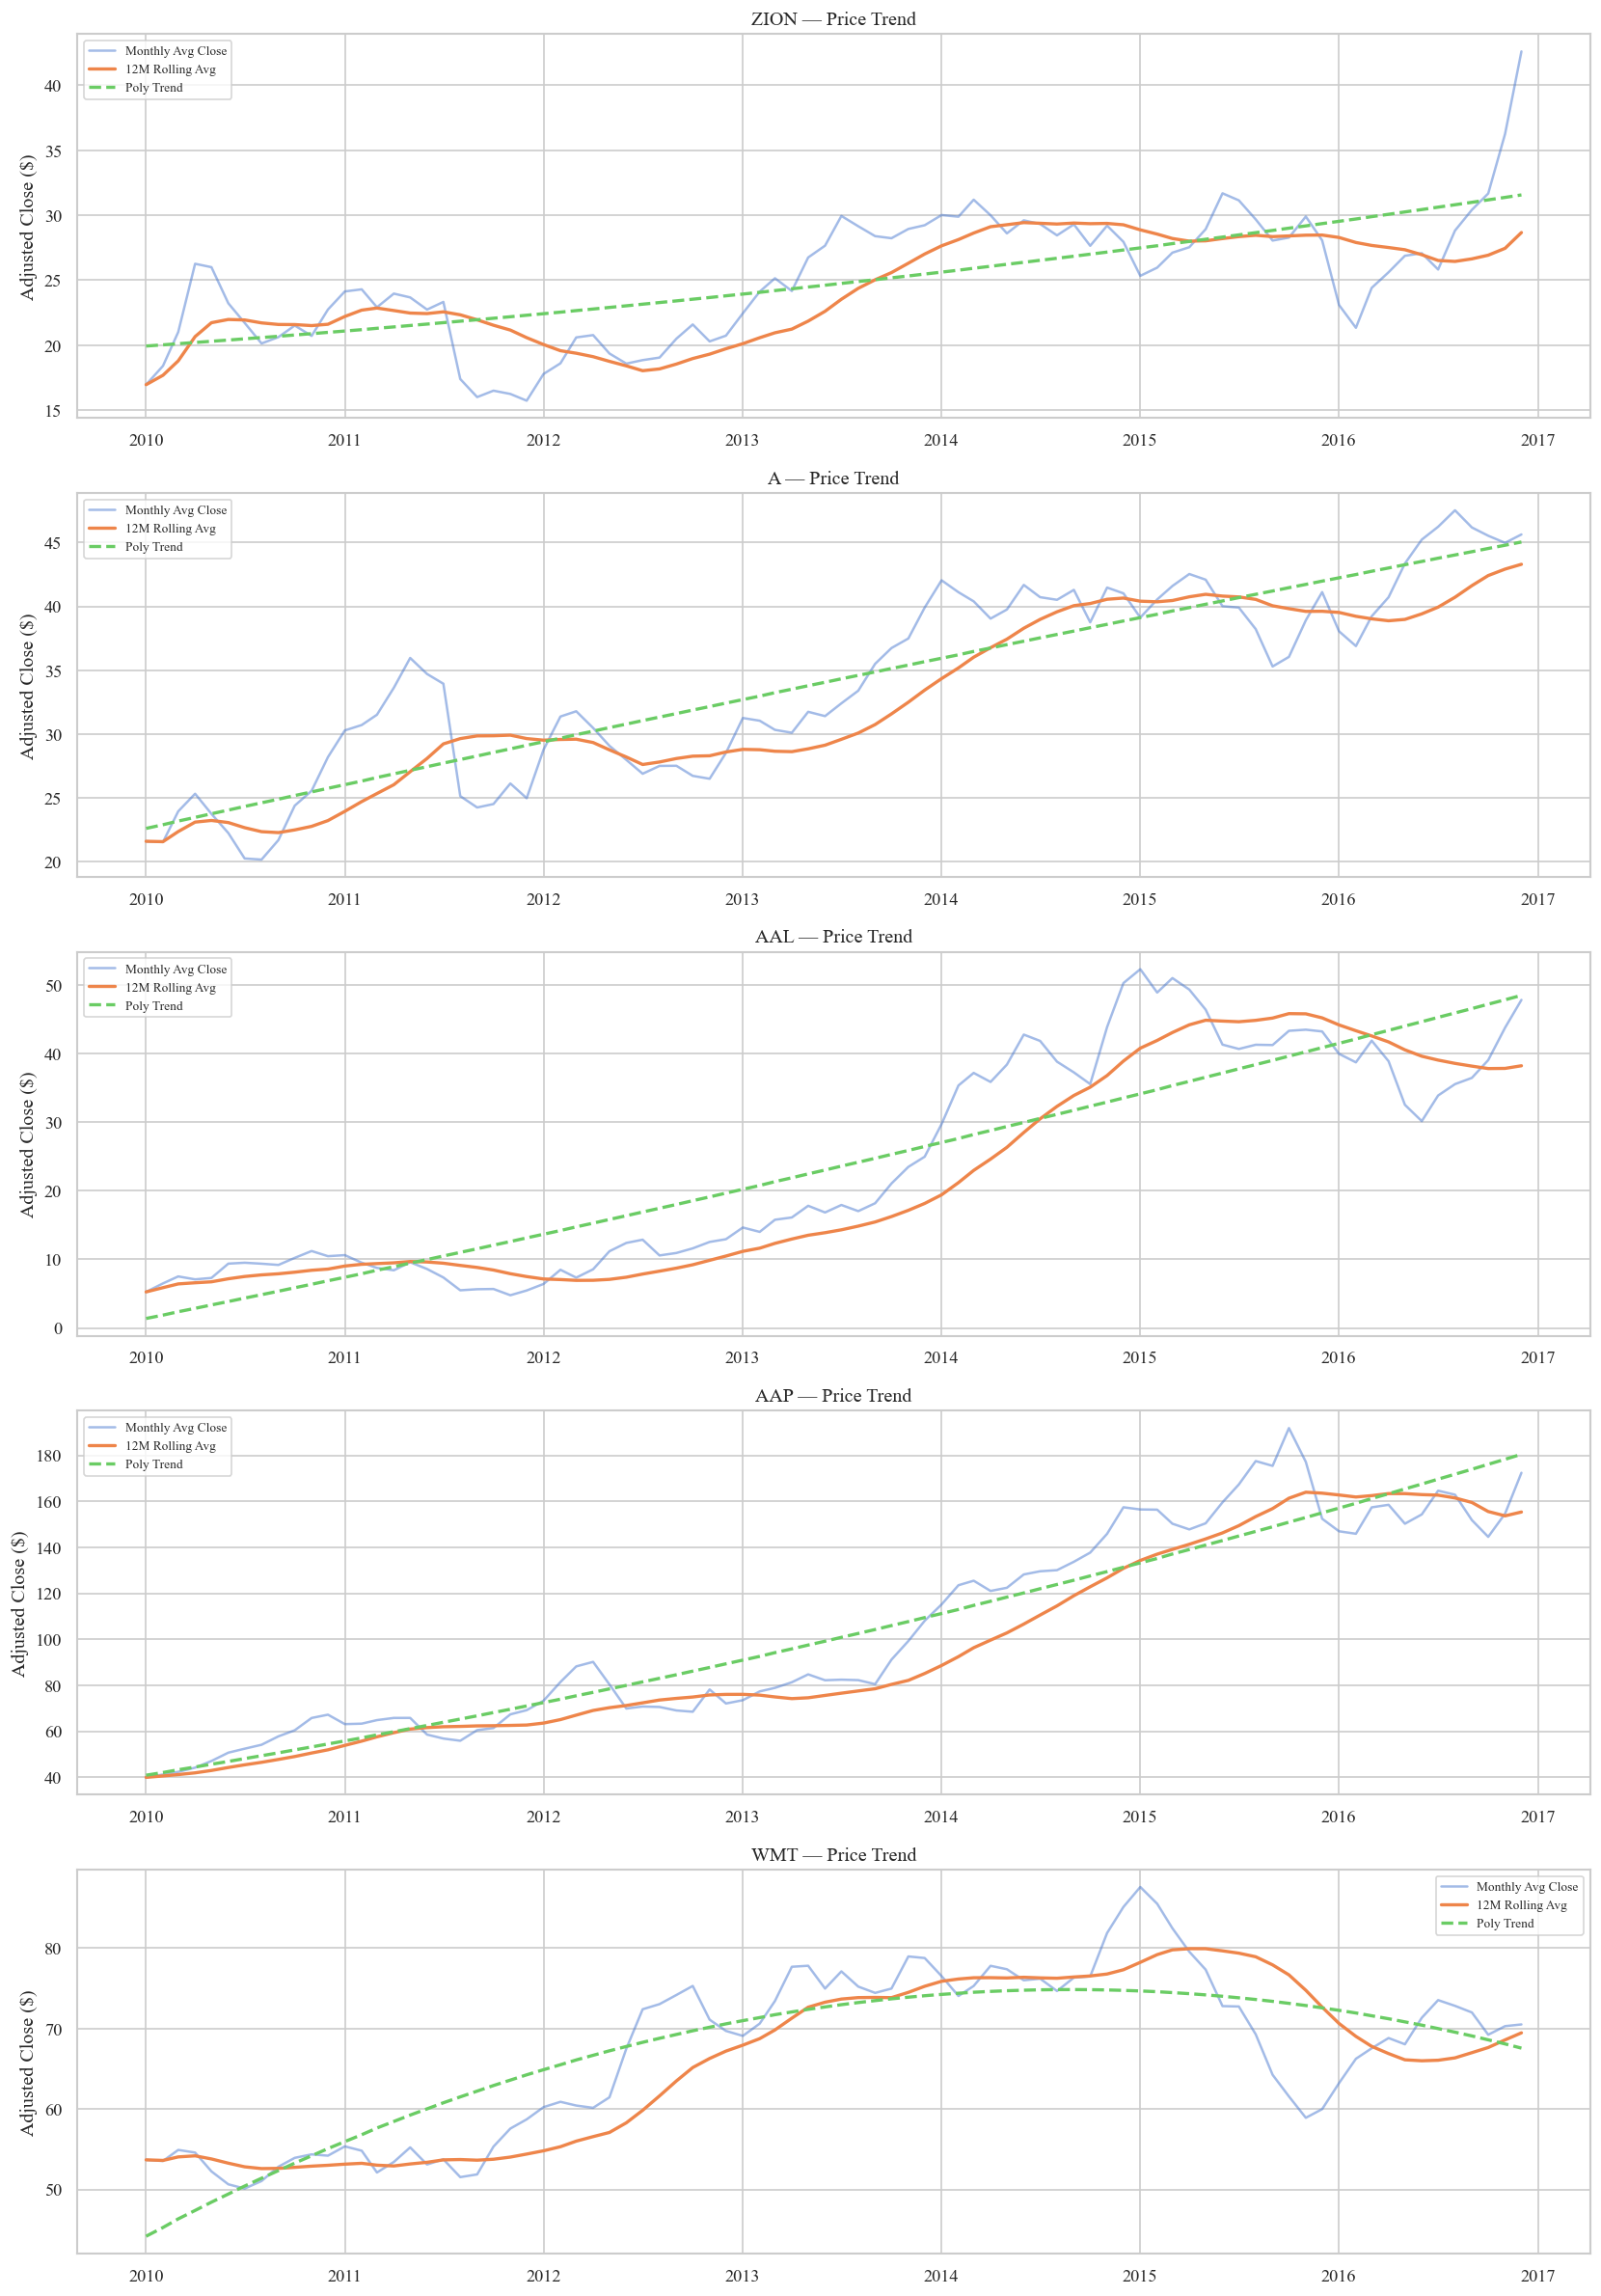

In [66]:
# 6.(b) Rolling Average and Trend Line.

fig, axes = plt.subplots(len(top5), 1, figsize=(14, 4 * len(top5)), sharex=False)

for ax, sym in zip(axes, top5):
    df_sym = monthly_price[monthly_price['symbol'] == sym].copy().reset_index(drop=True)
    df_sym['t'] = np.arange(len(df_sym))

    # Polynomial trend (degree 2)
    model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    model.fit(df_sym[['t']], df_sym['avg_close'])
    df_sym['trend'] = model.predict(df_sym[['t']])

    # 12-month rolling average
    df_sym['rolling_12'] = df_sym['avg_close'].rolling(12, min_periods=1).mean()

    ax.plot(df_sym['yearmonth'], df_sym['avg_close'],  alpha=0.5, label='Monthly Avg Close')
    ax.plot(df_sym['yearmonth'], df_sym['rolling_12'], linewidth=2, label='12M Rolling Avg')
    ax.plot(df_sym['yearmonth'], df_sym['trend'],      linewidth=2, linestyle='--', label='Poly Trend')
    ax.set_title(f'{sym} — Price Trend')
    ax.set_ylabel('Adjusted Close ($)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

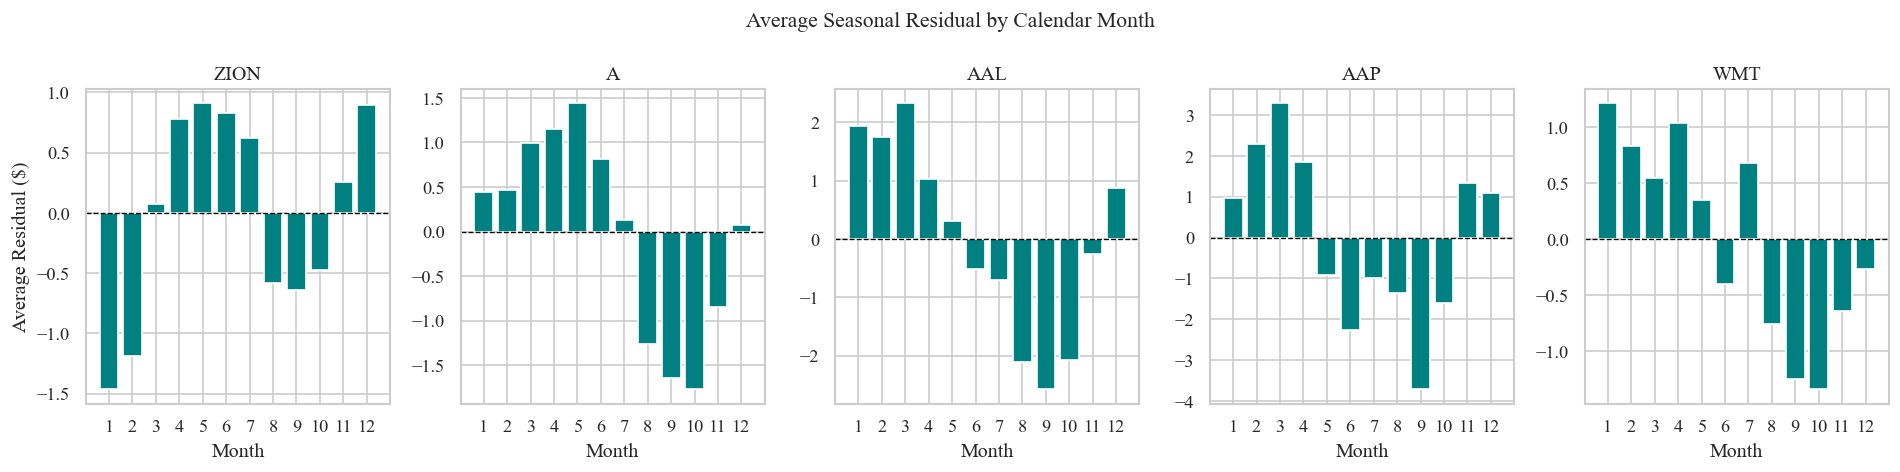

In [67]:
# 6.(c) Seasonal Residual Analysis.

fig, axes = plt.subplots(1, len(top5), figsize=(16, 4), sharey=False)

for ax, sym in zip(axes, top5):
    df_sym = monthly_price[monthly_price['symbol'] == sym].copy().reset_index(drop=True)
    df_sym['t'] = np.arange(len(df_sym))

    model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    model.fit(df_sym[['t']], df_sym['avg_close'])
    df_sym['residual'] = df_sym['avg_close'] - model.predict(df_sym[['t']])

    df_sym['cal_month'] = pd.to_datetime(df_sym['yearmonth']).dt.month
    seasonal = df_sym.groupby('cal_month')['residual'].mean()

    ax.bar(seasonal.index, seasonal.values, color='teal', edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(sym)
    ax.set_xlabel('Month')
    ax.set_xticks(range(1, 13))

axes[0].set_ylabel('Average Residual ($)')
plt.suptitle('Average Seasonal Residual by Calendar Month', fontsize=13)
plt.tight_layout()
plt.show()

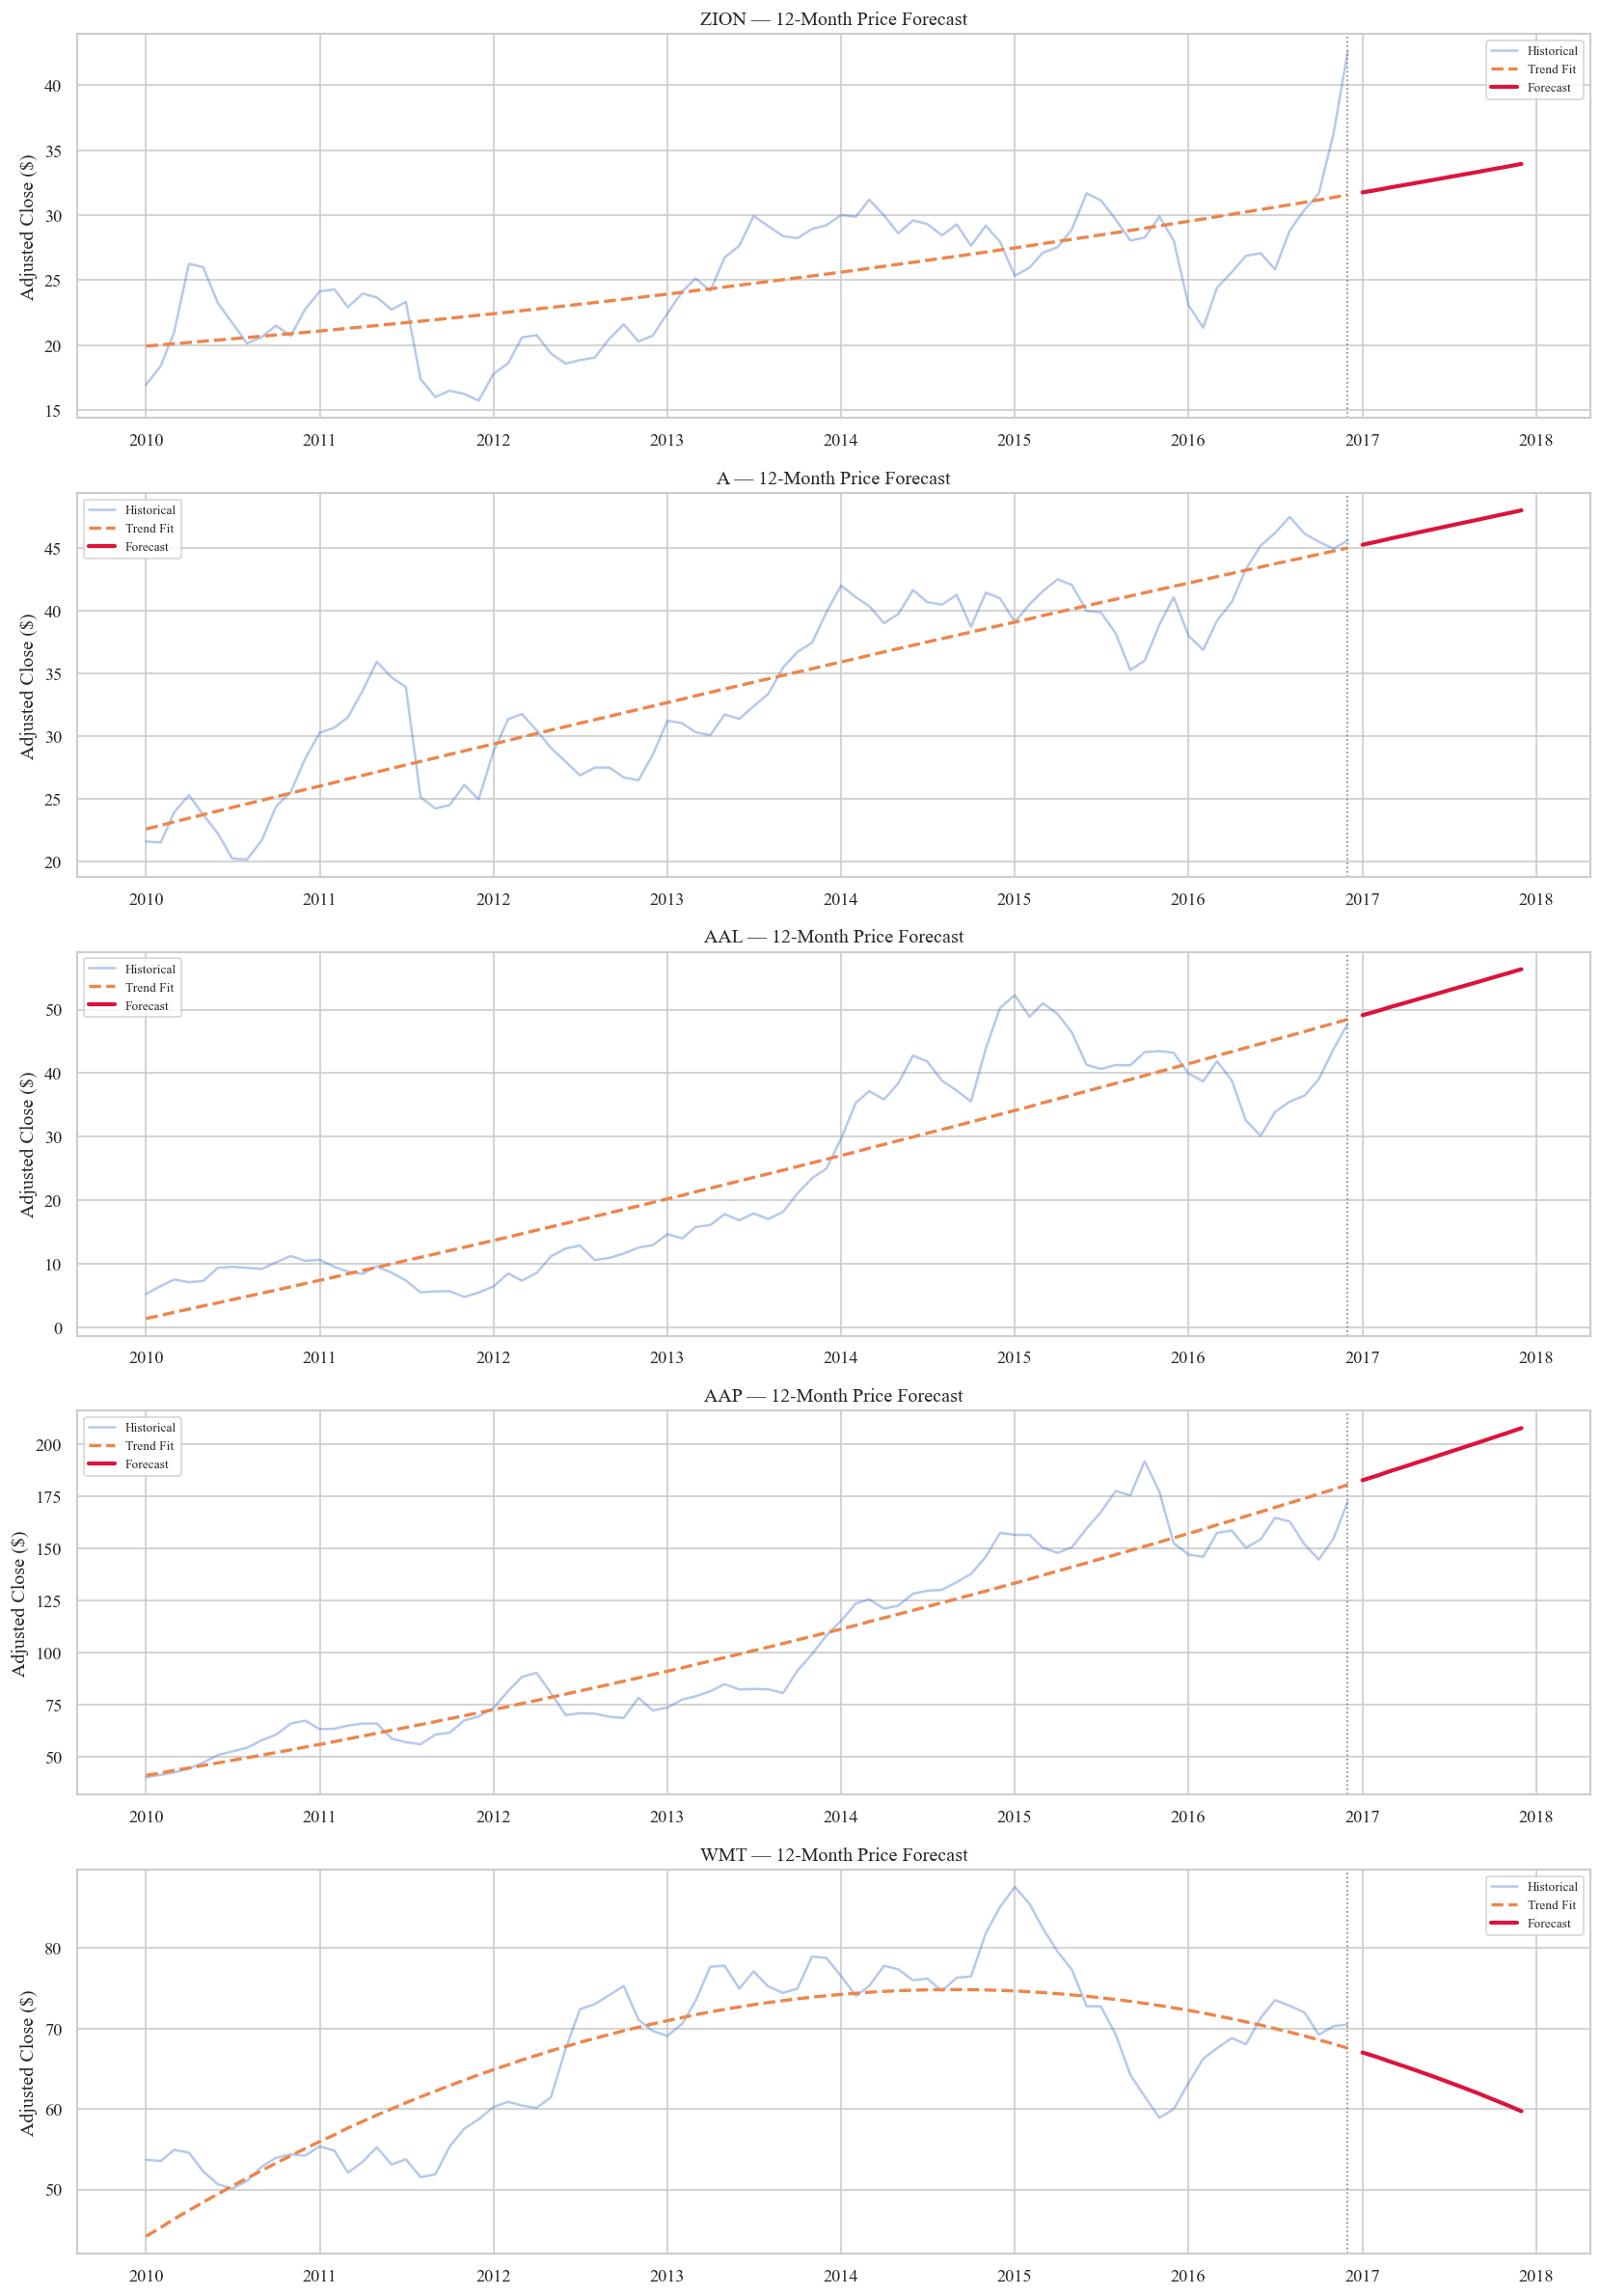

In [68]:
# 7. Price Forecasting — Next 12 Months (Top 5 Companies).

forecast_records = []

fig, axes = plt.subplots(len(top5), 1, figsize=(14, 4 * len(top5)), sharex=False)

for ax, sym in zip(axes, top5):
    df_sym = monthly_price[monthly_price['symbol'] == sym].copy().reset_index(drop=True)
    df_sym['t'] = np.arange(len(df_sym))

    model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    model.fit(df_sym[['t']], df_sym['avg_close'])
    df_sym['fitted'] = model.predict(df_sym[['t']])

    last_t     = df_sym['t'].max()
    last_date  = df_sym['yearmonth'].max()
    future_t   = np.arange(last_t + 1, last_t + 13).reshape(-1, 1)
    future_dates  = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=12, freq='MS')
    future_prices = model.predict(future_t).clip(0)

    ax.plot(df_sym['yearmonth'], df_sym['avg_close'], alpha=0.4, label='Historical')
    ax.plot(df_sym['yearmonth'], df_sym['fitted'],    linewidth=2, linestyle='--', label='Trend Fit')
    ax.plot(future_dates, future_prices,              linewidth=2.5, color='crimson', label='Forecast')
    ax.axvline(last_date, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{sym} — 12-Month Price Forecast')
    ax.set_ylabel('Adjusted Close ($)')
    ax.legend(fontsize=8)

    for date, price in zip(future_dates, future_prices):
        forecast_records.append({'symbol': sym, 'date': date, 'forecast_close': round(price, 2)})

plt.tight_layout()
plt.show()

In [69]:
forecast_df = pd.DataFrame(forecast_records)
print(f'Forecast rows: {len(forecast_df)}')
display(forecast_df.head(15))

forecast_df.to_csv('forecast_top5_prices.csv', index=False)
print('Saved: forecast_top5_prices.csv')

Forecast rows: 60


,symbol,date,forecast_close
0,ZION,2017-01-01,32
1,ZION,2017-02-01,32
2,ZION,2017-03-01,32
3,ZION,2017-04-01,32
4,ZION,2017-05-01,33
5,ZION,2017-06-01,33
6,ZION,2017-07-01,33
7,ZION,2017-08-01,33
8,ZION,2017-09-01,33
9,ZION,2017-10-01,34


Saved: forecast_top5_prices.csv


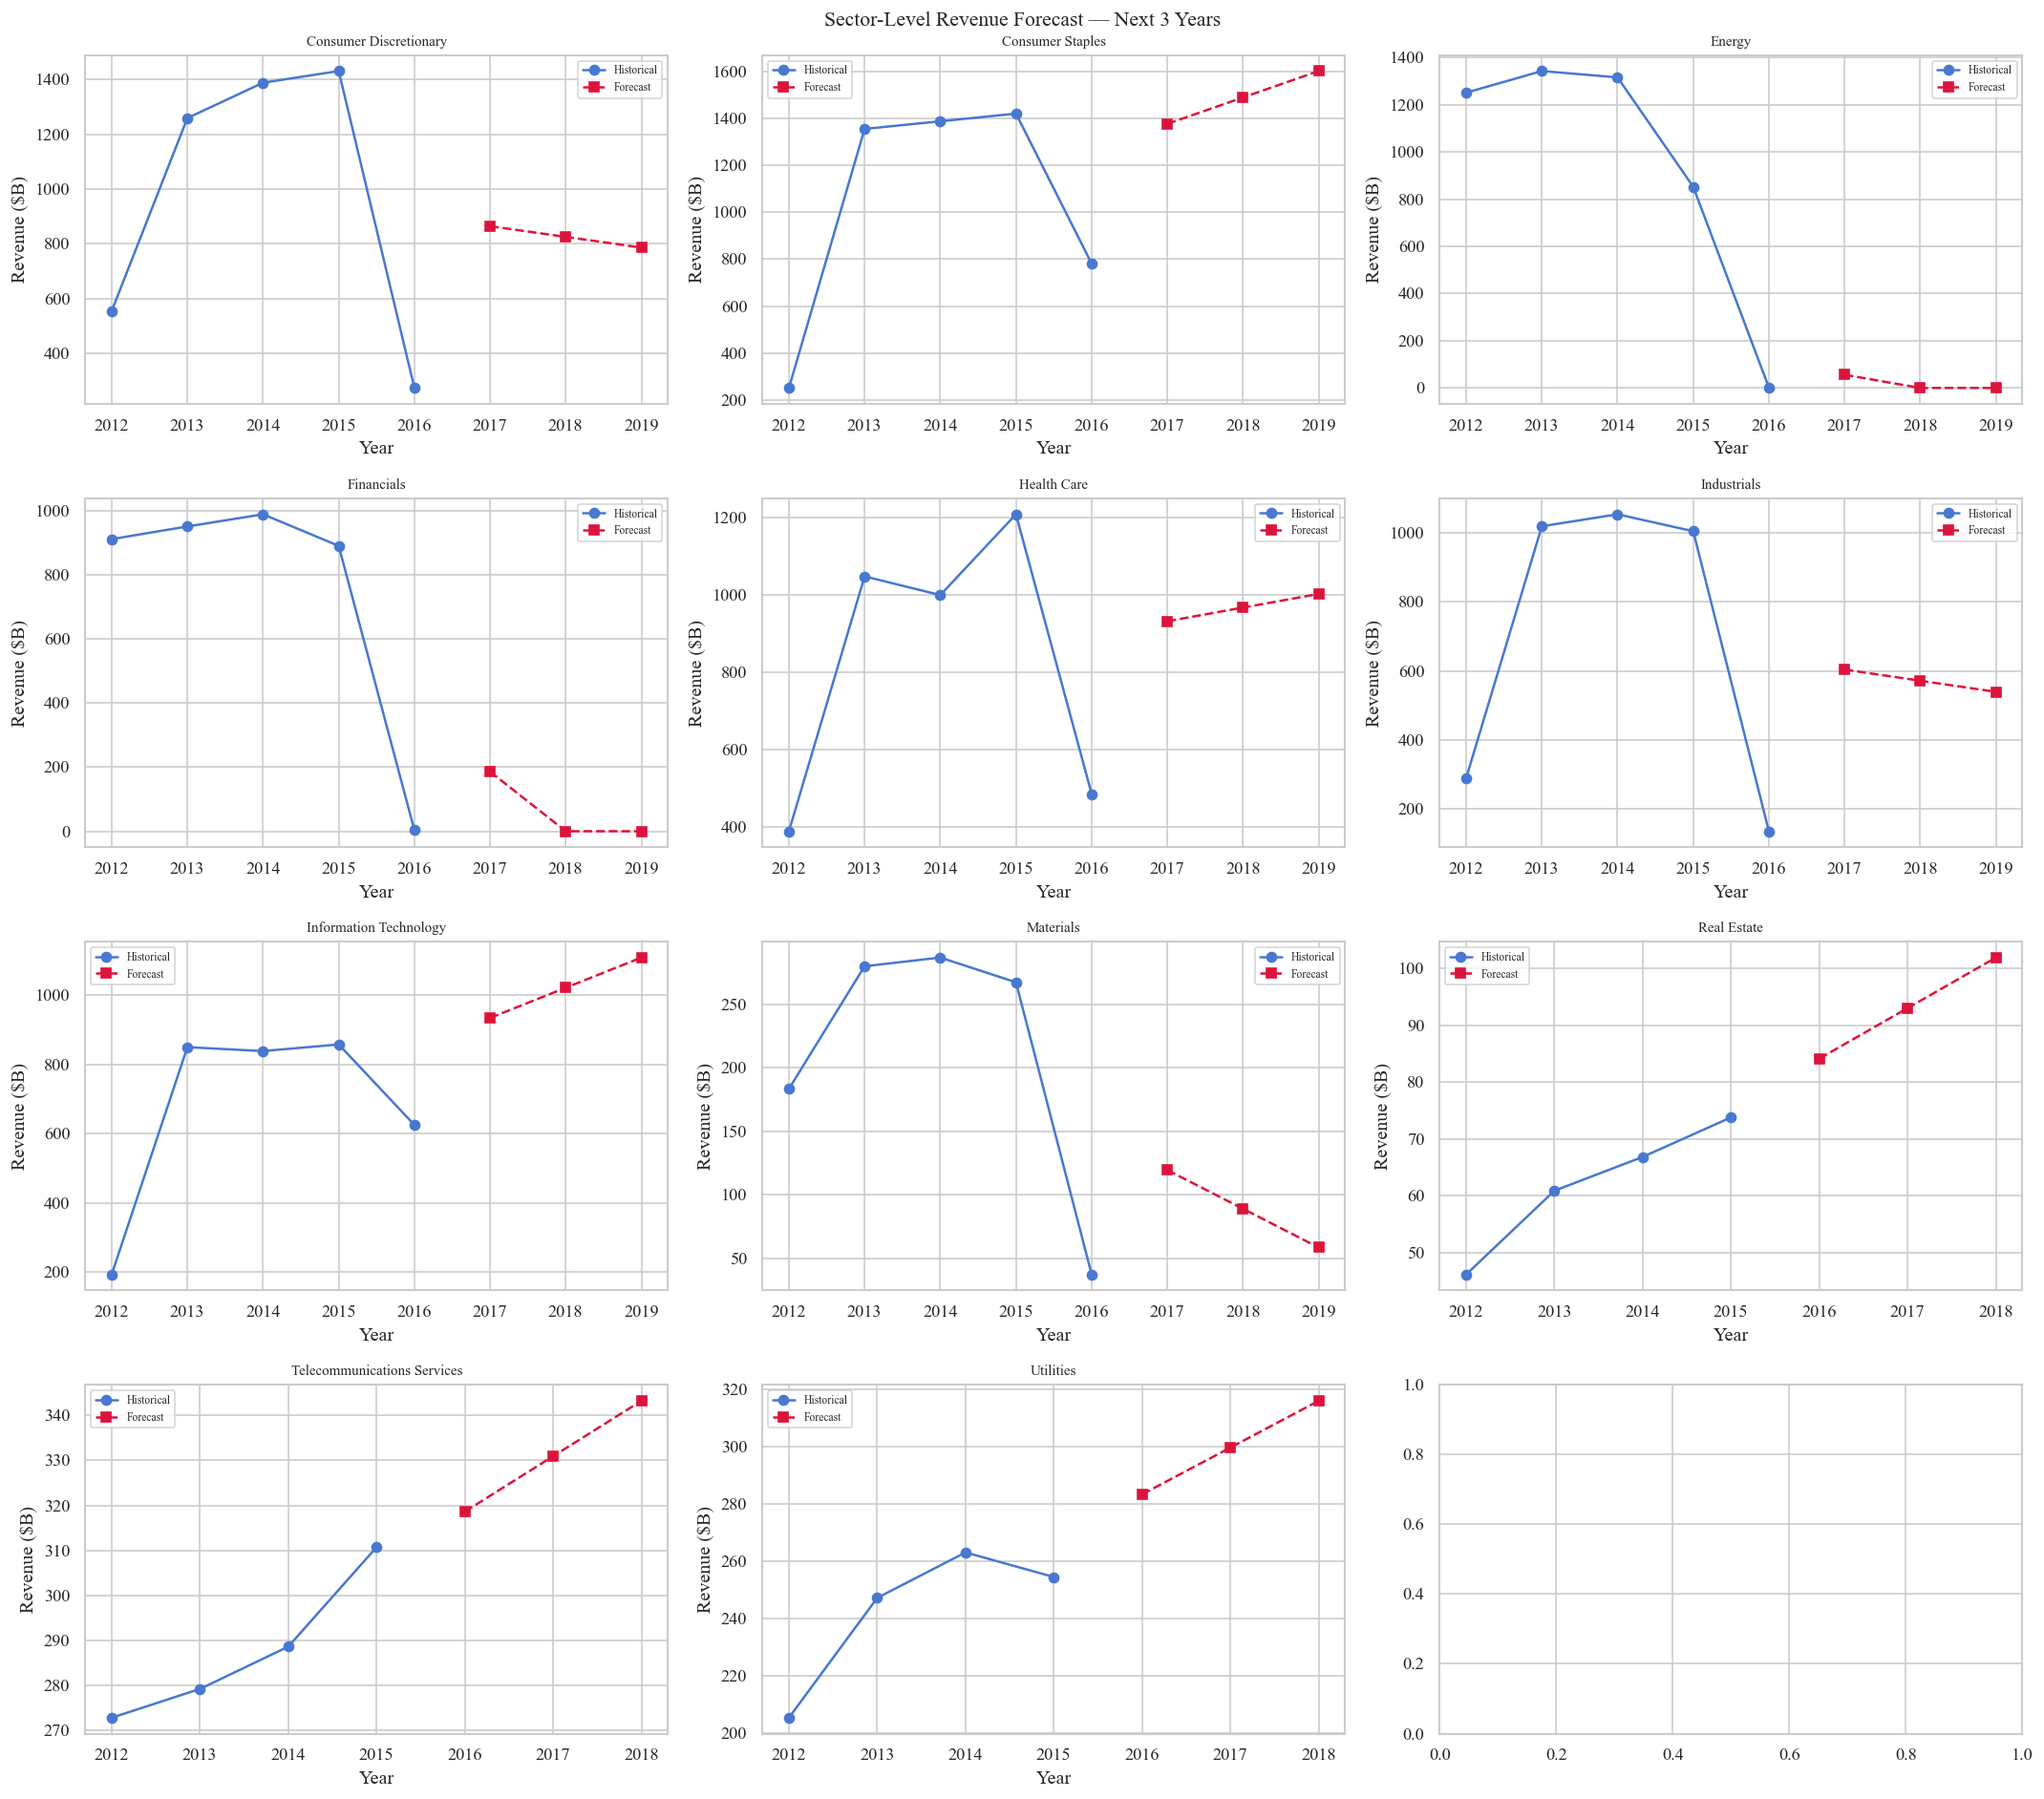

In [70]:
# 8. Category-Level Forecasting — Revenue by GICS Sector.

# Annual total revenue is aggregated by sector, then a linear trend model forecasts the next 3 years.

sector_annual = (
    funds.dropna(subset=['sector', 'total_revenue'])
    .groupby(['sector', 'for_year'])['total_revenue']
    .sum()
    .reset_index()
    .rename(columns={'total_revenue': 'total_revenue_sum'})
)

sectors = sector_annual['sector'].dropna().unique()
rev_forecast_records = []

ncols = 3
nrows = int(np.ceil(len(sectors) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flat

for ax, sector in zip(axes, sectors):
    df_s = sector_annual[sector_annual['sector'] == sector].sort_values('for_year').copy()
    if len(df_s) < 3:
        ax.set_visible(False)
        continue

    X = df_s['for_year'].values.reshape(-1, 1)
    y = df_s['total_revenue_sum'].values

    model = LinearRegression().fit(X, y)
    future_years  = np.array([df_s['for_year'].max() + i for i in range(1, 4)]).reshape(-1, 1)
    future_rev    = model.predict(future_years).clip(0)

    ax.plot(df_s['for_year'], y / 1e9, marker='o', label='Historical')
    ax.plot(future_years.flatten(), future_rev / 1e9,
            marker='s', linestyle='--', color='crimson', label='Forecast')
    ax.set_title(sector, fontsize=9)
    ax.set_xlabel('Year')
    ax.set_ylabel('Revenue ($B)')
    ax.legend(fontsize=7)

    for yr, rev in zip(future_years.flatten(), future_rev):
        rev_forecast_records.append({'sector': sector, 'year': int(yr), 'forecast_revenue': round(rev, 0)})

for ax in axes:
    if not ax.get_visible() or not ax.lines:
        ax.set_visible(False)

plt.suptitle('Sector-Level Revenue Forecast — Next 3 Years', fontsize=13)
plt.tight_layout()
plt.show()


In [71]:
rev_forecast_df = pd.DataFrame(rev_forecast_records)
print(f'Sector forecast rows: {len(rev_forecast_df)}')
display(rev_forecast_df)

rev_forecast_df.to_csv('forecast_sector_revenue.csv', index=False)
print('Saved: forecast_sector_revenue.csv')

Sector forecast rows: 33


,sector,year,forecast_revenue
0,Consumer Discretionary,2017,"864,439,392,200"
1,Consumer Discretionary,2018,"825,503,502,000"
2,Consumer Discretionary,2019,"786,567,611,800"
3,Consumer Staples,2017,"1,376,476,295,000"
4,Consumer Staples,2018,"1,488,993,117,600"
5,Consumer Staples,2019,"1,601,509,940,200"
6,Energy,2017,"56,119,430,100"
7,Energy,2018,0
8,Energy,2019,0
9,Financials,2017,"185,573,148,600"


Saved: forecast_sector_revenue.csv


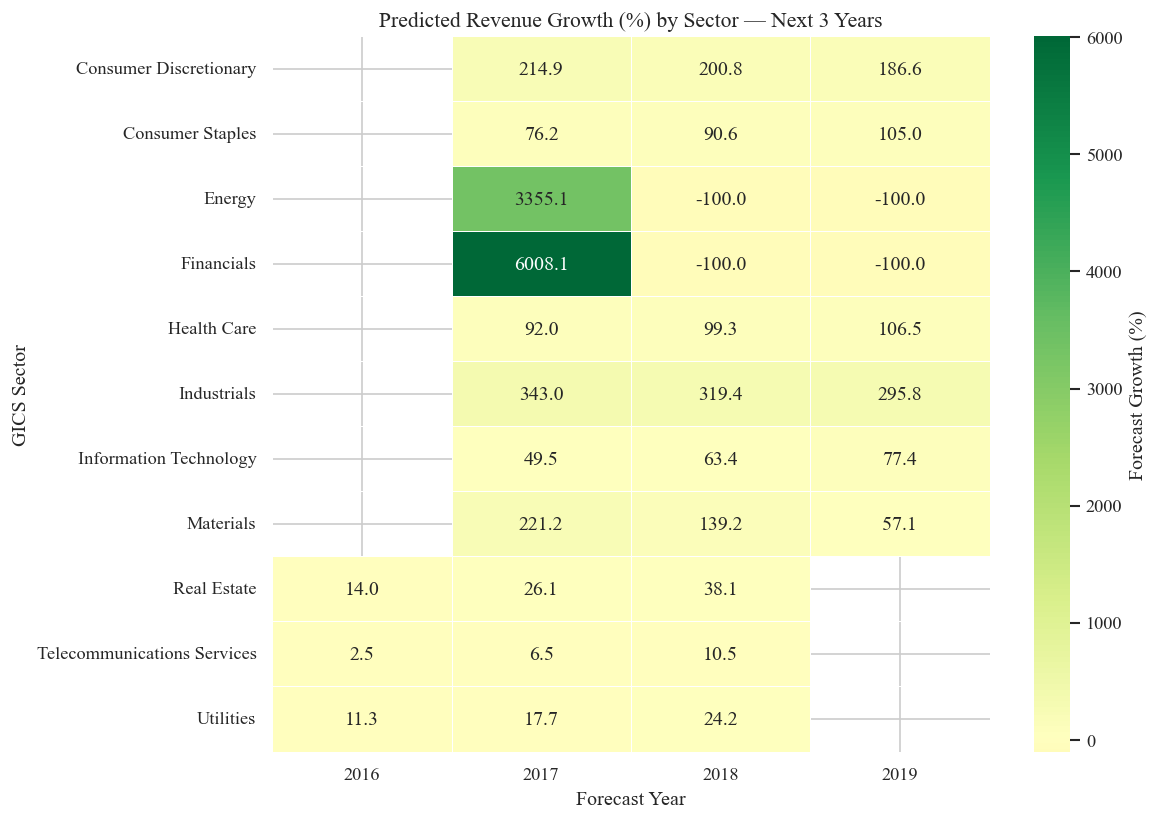

In [72]:
# # 9. Sector Heatmap — Predicted Revenue Growth

# Percentage growth in forecast revenue relative to the last observed year.

last_obs = (
    sector_annual.sort_values('for_year')
    .groupby('sector')
    .last()
    .reset_index()[['sector', 'for_year', 'total_revenue_sum']]
    .rename(columns={'total_revenue_sum': 'base_revenue', 'for_year': 'base_year'})
)

heat = rev_forecast_df.merge(last_obs, on='sector', how='left')
heat['growth_pct'] = ((heat['forecast_revenue'] - heat['base_revenue']) / heat['base_revenue']) * 100

heat_pivot = heat.pivot(index='sector', columns='year', values='growth_pct')

plt.figure(figsize=(10, 7))
sns.heatmap(
    heat_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
    center=0, linewidths=0.5, cbar_kws={'label': 'Forecast Growth (%)'}
)
plt.title('Predicted Revenue Growth (%) by Sector — Next 3 Years', fontsize=13)
plt.xlabel('Forecast Year')
plt.ylabel('GICS Sector')
plt.tight_layout()
plt.show()


In [73]:
# 10. Model Performance Summary

# MAE, RMSE, and R² computed on the training set for the polynomial trend model (top 5 companies).

rows = []
for sym in top5:
    df_sym = monthly_price[monthly_price['symbol'] == sym].copy().reset_index(drop=True)
    df_sym['t'] = np.arange(len(df_sym))

    model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    model.fit(df_sym[['t']], df_sym['avg_close'])
    preds = model.predict(df_sym[['t']])

    mae  = mean_absolute_error(df_sym['avg_close'], preds)
    rmse = mean_squared_error(df_sym['avg_close'], preds) ** 0.5
    r2   = r2_score(df_sym['avg_close'], preds)
    rows.append({'Symbol': sym, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4)})

perf_df = pd.DataFrame(rows)
display(perf_df)


,Symbol,MAE,RMSE,R2
0,ZION,3,4,0
1,A,3,3,1
2,AAL,6,7,1
3,AAP,11,14,1
4,WMT,4,6,1


In [74]:
# # 11. Conclusions and Recommendations.

# 1. **Price distribution** — Most S&P 500 adjusted close prices fall below $200, with a right-skewed distribution. The log-transformed histogram approximates normality, which supports log-return modelling in downstream work.

# 2. **Financial metrics over time** — Median revenue and net income have grown steadily across the available years. EPS shows more volatility, particularly around 2008–2009.

# 3. **Sector patterns** — Energy and Financials lead in total revenue. Technology and Health Care show the highest profit margins and R&D investment, making them strong candidates for long-term growth.

# 4. **Trend and seasonality** — The polynomial trend model captures the broad upward trajectory for most large-cap stocks. Seasonal residuals show mild patterns, with slight weakness in summer months and a tendency to recover toward year-end.

# 5. **12-month price forecast** — Forecast prices for the top 5 companies continue the existing trend. Tickers with R² above 0.85 offer the most reliable forward estimates.

# 6. **Sector revenue forecast** — Technology and Health Care are projected to show the strongest percentage revenue growth, while Energy exhibits greater uncertainty tied to commodity price cycles.

# **Actionable recommendations:**
# - Prioritise **Technology and Health Care** sectors for long-term portfolio positioning based on both fundamental strength and growth trajectory.
# - **Energy** may offer undervalued entry points at the right time, but requires close monitoring of commodity cycles before significant allocation.
# - Companies with high R² trend fits and consistent EPS growth — visible in `forecast_top5_prices.csv` — are the most straightforward candidates for price-momentum strategies.